In [ ]:
import os
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

/Applications/anaconda3/envs/CS3700/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_dir = os.path.expanduser("~/.cache/kagglehub/datasets/rounakbanik/pokemon")

if os.path.exists(dataset_dir):
    print("already downloaded")
    path = dataset_dir
else:
    path = kagglehub.dataset_download("rounakbanik/pokemon")

csv_path = os.path.join(path, "versions/1/pokemon.csv")
df = pd.read_csv(csv_path)

print("path to dataset:", csv_path)


already downloaded
path to dataset: /Users/modigr/.cache/kagglehub/datasets/rounakbanik/pokemon/versions/1/pokemon.csv


inspection and data cleansing


In [ ]:
print(df["is_legendary"].value_counts())
print(df["is_legendary"].value_counts(normalize=True))
print(df.isnull().sum().sort_values(ascending=False).head(20))

is_legendary
0    731
1     70
Name: count, dtype: int64
is_legendary
0    0.912609
1    0.087391
Name: proportion, dtype: float64
type2                384
percentage_male       98
weight_kg             20
height_m              20
name                   0
capture_rate           0
classfication          0
defense                0
experience_growth      0
hp                     0
japanese_name          0
abilities              0
base_happiness         0
pokedex_number         0
sp_attack              0
sp_defense             0
speed                  0
type1                  0
generation             0
base_total             0
dtype: int64


In [ ]:
# features that I deem worthy of keeping after inspecting the dataset (and based on my own personal pokemon knowledge :) )
keep_cols = ["attack", "base_egg_steps", "base_happiness", "capture_rate", "defense", "experience_growth", "hp", "sp_attack", "sp_defense", "speed", "weight_kg"]
target_col = "is_legendary"

df["capture_rate"] = df["capture_rate"].astype(str).str.extract(r"(\d+)").astype(float)
df_model = df[keep_cols + [target_col]].copy()

X = df_model.drop(columns=[target_col])
y = df_model[target_col]


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [22]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

numeric_preprocessor = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline

logreg_model = Pipeline([("preprocessor", numeric_preprocessor), ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))])

# train the model
logreg_model.fit(X_train, y_train)

# make predictions
y_pred_log = logreg_model.predict(X_test)
y_prob_log = logreg_model.predict_proba(X_test)[:, 1]

# evaluate
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("Classification Report:")
print(classification_report(y_test, y_pred_log))


Logistic Regression Results
Accuracy: 0.9813664596273292
ROC-AUC: 0.9961127308066083
Confusion Matrix:
[[145   2]
 [  1  13]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       147
           1       0.87      0.93      0.90        14

    accuracy                           0.98       161
   macro avg       0.93      0.96      0.94       161
weighted avg       0.98      0.98      0.98       161



In [24]:
misclassified = X_test.copy()
misclassified["actual"] = y_test.values
misclassified["predicted"] = y_pred_log
misclassified["pred_prob_legendary"] = y_prob_log

errors = misclassified[misclassified["actual"] != misclassified["predicted"]]
print(errors)


     attack  base_egg_steps  base_happiness  capture_rate  defense  \
281      85            5120              35          45.0       65   
64       50            5120              70          50.0       65   
797     181           30720               0         255.0      131   

     experience_growth  hp  sp_attack  sp_defense  speed  weight_kg  actual  \
281            1250000  68        165         135    100       48.4       0   
64             1059860  55        175         105    150       48.0       0   
797            1250000  59         59          31    109        0.1       1   

     predicted  pred_prob_legendary  
281          1             0.660094  
64           1             0.622278  
797          0             0.261789  


In [25]:
feature_names = X_train.columns
coefficients = logreg_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefficients, "abs_coefficient": np.abs(coefficients)})
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)
print(coef_df)


              feature  coefficient  abs_coefficient
3        capture_rate    -2.150557         2.150557
1      base_egg_steps     2.107769         2.107769
5   experience_growth     1.454085         1.454085
7           sp_attack     0.890597         0.890597
9               speed     0.602242         0.602242
2      base_happiness     0.460076         0.460076
8          sp_defense     0.372005         0.372005
6                  hp    -0.317665         0.317665
4             defense     0.194750         0.194750
0              attack     0.162657         0.162657
10          weight_kg    -0.011894         0.011894


Random Forest Results
Accuracy: 1.0
ROC-AUC: 1.0
Confusion Matrix:
[[147   0]
 [  0  14]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       147
           1       1.00      1.00      1.00        14

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161

              feature  importance
1      base_egg_steps    0.333304
3        capture_rate    0.194798
5   experience_growth    0.182013
7           sp_attack    0.067536
2      base_happiness    0.060141
8          sp_defense    0.047643
9               speed    0.039367
6                  hp    0.028965
0              attack    0.022029
10          weight_kg    0.013572
4             defense    0.010634


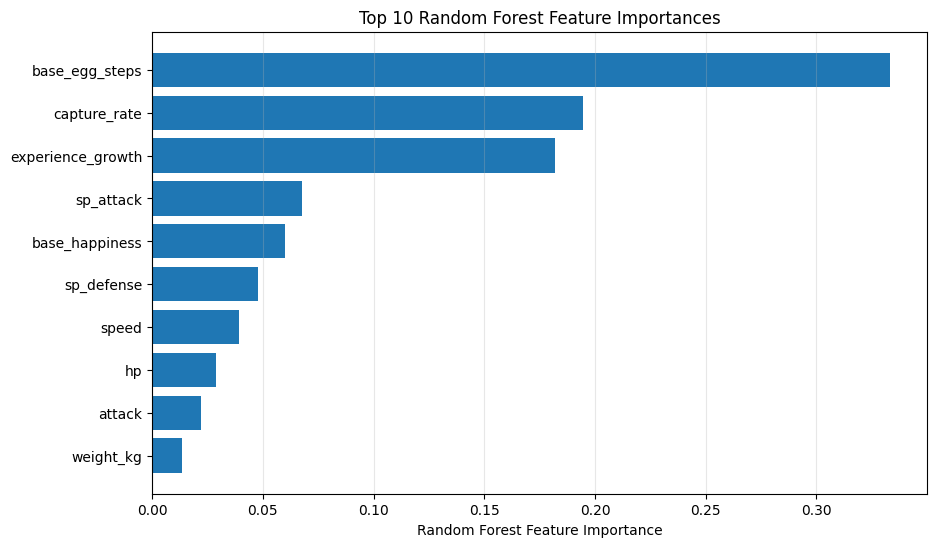

In [27]:
from sklearn.ensemble import RandomForestClassifier

# trying a tree model too since it can pick up nonlinear patterns more naturally
rf_preprocessor = Pipeline([("imputer", SimpleImputer(strategy="median"))])
rf_model = Pipeline([("preprocessor", rf_preprocessor), ("classifier", RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"))])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

rf_importances = rf_model.named_steps["classifier"].feature_importances_
rf_df = pd.DataFrame({"feature": X_train.columns, "importance": rf_importances}).sort_values("importance", ascending=False)
print(rf_df)

top_rf = rf_df.head(10).sort_values("importance")
plt.figure(figsize=(10, 6))
plt.barh(top_rf["feature"], top_rf["importance"])
plt.xlabel("Random Forest Feature Importance")
plt.title("Top 10 Random Forest Feature Importances")
plt.grid(True, axis="x", alpha=0.3)
plt.show()


In [28]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1", "roc_auc": "roc_auc"}

logreg_cv = cross_validate(logreg_model, X, y, cv=cv, scoring=scoring)
rf_cv = cross_validate(rf_model, X, y, cv=cv, scoring=scoring)

# just wrapping this in a helper so the final comparison table is cleaner
def summarize_cv_results(results, model_name):
    return {
        "Model": model_name,
        "Accuracy Mean": results["test_accuracy"].mean(),
        "Accuracy Std": results["test_accuracy"].std(),
        "Precision Mean": results["test_precision"].mean(),
        "Recall Mean": results["test_recall"].mean(),
        "F1 Mean": results["test_f1"].mean(),
        "ROC-AUC Mean": results["test_roc_auc"].mean(),
    }

cv_results_df = pd.DataFrame([summarize_cv_results(logreg_cv, "Logistic Regression"), summarize_cv_results(rf_cv, "Random Forest")])
print(cv_results_df)


                 Model  Accuracy Mean  Accuracy Std  Precision Mean  \
0  Logistic Regression       0.965062      0.015553        0.746625   
1        Random Forest       0.996258      0.003056        0.960000   

   Recall Mean   F1 Mean  ROC-AUC Mean  
0     0.928571  0.825997      0.993944  
1     1.000000  0.979310      0.999609  
